## 5. Feature Importance Analysis

This notebook computes and compares feature importance across all three models (Sub-question 4). To ensure a fair and consistent comparison, permutation importance is used for all three models. This method measures how much model performance decreases when a feature's values are randomly shuffled, and can be applied to any model regardless of its internal structure.

### Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from autogluon.tabular import TabularPredictor
from tabpfn_client import TabPFNClassifier as CloudTabPFN, init
from utils import load_and_preprocess, get_train_test_split

init()  
os.makedirs('figures', exist_ok=True)
print('Setup complete!')

Setup complete!


### Data Loading and Preprocessing

In [3]:
X_xgb, X_auto, y = load_and_preprocess('Churn_Modelling.csv')

X_train_xgb, X_test_xgb, y_train, y_test = get_train_test_split(X_xgb.astype(float), y, seed=0)
X_train_auto, X_test_auto, _, _ = get_train_test_split(X_auto, y, seed=0)

print('Data loaded!')

Data loaded!


### XGBoost Permutation Importance

In [4]:
xgb_model = XGBClassifier(random_state=0, eval_metric='logloss')
xgb_model.fit(X_train_xgb, y_train)

perm_xgb = permutation_importance(xgb_model, X_test_xgb, y_test,
                                   n_repeats=10, random_state=0, scoring='roc_auc')
xgb_perm_fi = pd.Series(perm_xgb.importances_mean, index=X_xgb.columns).sort_values(ascending=True)

print('XGBoost done!')
print(xgb_perm_fi.sort_values(ascending=False).head(5))

XGBoost done!
NumOfProducts        0.120064
Age                  0.115864
Balance              0.041552
IsActiveMember       0.029172
Geography_Germany    0.023936
dtype: float64


### AutoGluon Permutation Importance

In [5]:
train_data_fi = X_train_auto.copy()
train_data_fi['Exited'] = y_train.values

save_path = 'agmodels/fi'
if os.path.exists(save_path): shutil.rmtree(save_path)

predictor_fi = TabularPredictor(label='Exited', path=save_path, verbosity=0)
predictor_fi.fit(train_data_fi, time_limit=120, presets='high_quality')

auto_fi = predictor_fi.feature_importance(train_data_fi)
auto_perm_fi = auto_fi['importance'].sort_values(ascending=True)

print('AutoGluon done!')
print(auto_perm_fi.sort_values(ascending=False).head(5))

AutoGluon done!
Age               0.08008
NumOfProducts     0.06520
IsActiveMember    0.03172
Geography         0.01840
Balance           0.01656
Name: importance, dtype: float64


### TabPFN Permutation Importance

In [6]:
clf_fi = CloudTabPFN(random_state=0)
clf_fi.fit(X_train_auto, y_train)

perm_tabpfn = permutation_importance(clf_fi, X_test_auto, y_test,
                                      n_repeats=10, random_state=0, scoring='roc_auc')
tabpfn_perm_fi = pd.Series(perm_tabpfn.importances_mean, index=X_auto.columns).sort_values(ascending=True)

shutil.rmtree('agmodels/fi')

print('TabPFN done!')
print(tabpfn_perm_fi.sort_values(ascending=False).head(5))

00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
00:00 Predicting... -

...

00:01 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
TabPFN done!
NumOfProducts     0.126361
Age               0.107530
Balance           0.058788
Geography         0.041566
IsActiveMember    0.030833
dtype: float64


### Feature Importance Comparison
Compare feature rankings across all three models side by side.

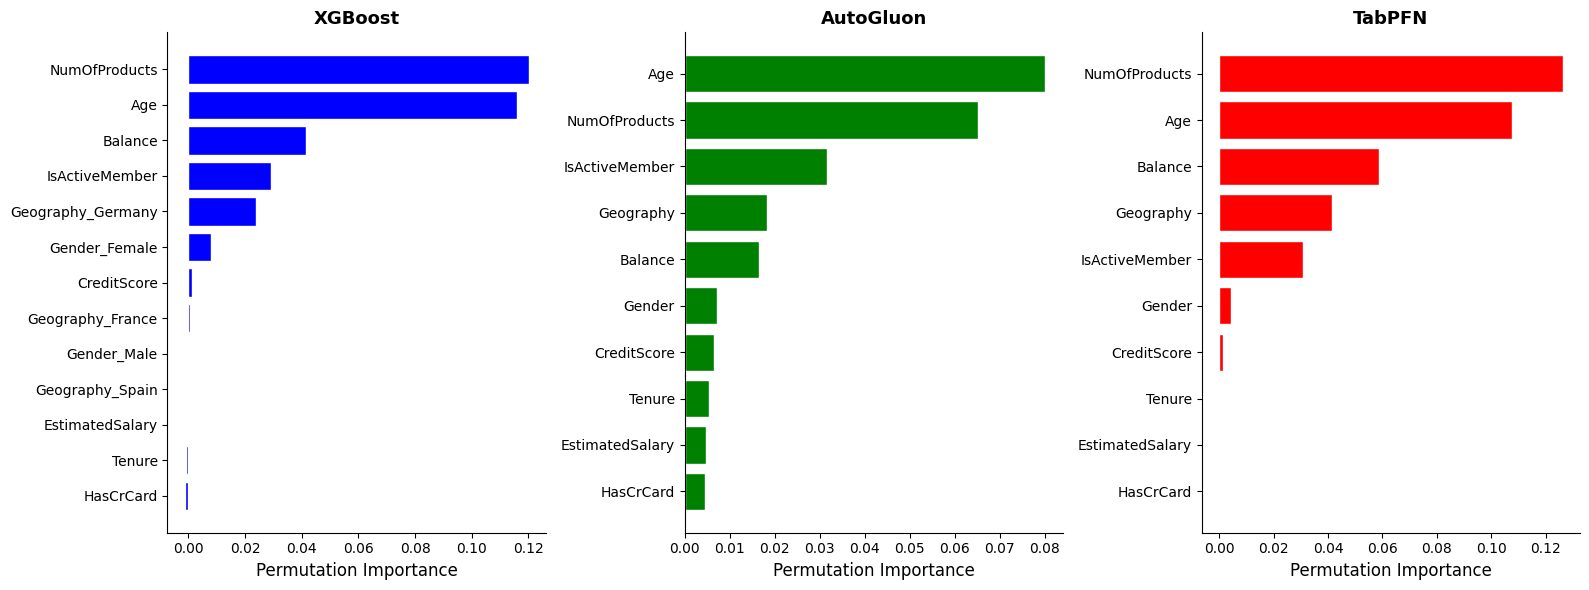

In [7]:
# Figure 11: Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, fi, color, title in zip(
    axes,
    [xgb_perm_fi, auto_perm_fi, tabpfn_perm_fi],
    ['blue', 'green', 'red'],
    ['XGBoost', 'AutoGluon', 'TabPFN']
):
    ax.barh(fi.index, fi.values, color=color, edgecolor='white')
    ax.set_xlabel('Permutation Importance', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/figure11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key findings

- NumOfProducts and Age were consistently among the most influential predictors across all three models.
- Other features differed in relative importance depending on the model, showing that different modelling approaches may rely on different patterns in the data.
- The feature importance results should be interpreted as predictive associations, not causal explanations of churn.